# Install Library

In [1]:
!pip install mealpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.8/168.8 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.3/423.3 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.9/17.9 MB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 82.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.0 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 

In [1]:
!pip install opfunu

# Import Library

In [2]:
# fundamental libraries
import numpy as np
import pandas as pd

# mealpy
from mealpy import FloatVar

# visualization
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns

# Connected to Drive

In [3]:
from google.colab import drive

# This will prompt for authorization.
# Make sure to follow the instructions and paste the authorization code.
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
path = "/content/drive/My Drive/Revision/"

# Define Necessary Function

## Benchmark Function

In [5]:
import sys
sys.path.append(path)

from benchmark_functions import classical_test_function

## Visualization Function

In [6]:
cmap = [(0, '#2f9599'), (0.45, '#eeeeee'), (1, '#8800ff')]
cmap = cm.colors.LinearSegmentedColormap.from_list('Custom', cmap, N=256)

def plot_3d(func, n_space=300, cmap=cmap, XYZ=None, ax=None, show=True, c1=1, c2=1, c3=1, name=None):
    X_domain, Y_domain = func.bounds
    if XYZ is None:
        X, Y = np.linspace(*X_domain, n_space), np.linspace(*Y_domain, n_space)
        X, Y = np.meshgrid(X, Y)
        XY = np.array([X, Y])
        Z = np.apply_along_axis(func.evaluate, 0, XY)
    else:
        X, Y, Z = XYZ

    # create new ax if None
    if ax is None:
        fig = plt.figure(figsize=(5, 5), dpi=300)
        ax = fig.add_subplot(1, 1, 1, projection='3d')
    else:
        fig = plt.figure(figsize=(18,20))
        ax = fig.add_subplot(c1, c2, c3, projection='3d')

    # Plot the surface.
    ax.plot_surface(X, Y, Z, cmap=cmap, linewidth=0, antialiased=True, alpha=0.7)
    ax.contour(X, Y, Z, zdir='z', levels=30, offset=np.min(Z), cmap=cmap)

    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False

    ax.set_xlabel('X', fontsize = 17)
    ax.set_ylabel('Y', fontsize = 17)
    ax.set_zlabel('Z', fontsize = 17)
    ax.set_title('{}'.format(name), fontsize = 20, fontweight='bold')
    ax.xaxis.set_tick_params(labelsize=16)
    ax.yaxis.set_tick_params(labelsize=16)
    ax.zaxis.set_tick_params(labelsize=16)

    plt.tight_layout()
    fig.savefig(path + f"figure/benchmark/{name}.png")
    fig.savefig(path + f"figure/benchmark/{name}.pdf", format="pdf", dpi=300, bbox_inches="tight")

# Define Problems

In [7]:
f_names, f_functions, f_problems, f_latexs = classical_test_function()

# Visualization 3D

In [8]:
plot_3d(f_functions[0], ax=None, name=f_names[0])
plot_3d(f_functions[1], ax=None, name=f_names[1])
plot_3d(f_functions[2], ax=None, name=f_names[2])
plot_3d(f_functions[3], ax=None, name=f_names[3])
plot_3d(f_functions[4], ax=None, name=f_names[4])
plot_3d(f_functions[5], ax=None, name=f_names[5])
plot_3d(f_functions[6], ax=None, name=f_names[6])
plot_3d(f_functions[7], ax=None, name=f_names[7])
plot_3d(f_functions[8], ax=None, name=f_names[8])
plot_3d(f_functions[9], ax=None, name=f_names[9])
plot_3d(f_functions[10], ax=None, name=f_names[10])
plot_3d(f_functions[11], ax=None, name=f_names[11])
plot_3d(f_functions[12], ax=None, name=f_names[12])
plot_3d(f_functions[13], ax=None, name=f_names[13])
plot_3d(f_functions[14], ax=None, name=f_names[14])
plot_3d(f_functions[15], ax=None, name=f_names[15])

Output hidden; open in https://colab.research.google.com to view.

## Get Figure for Article

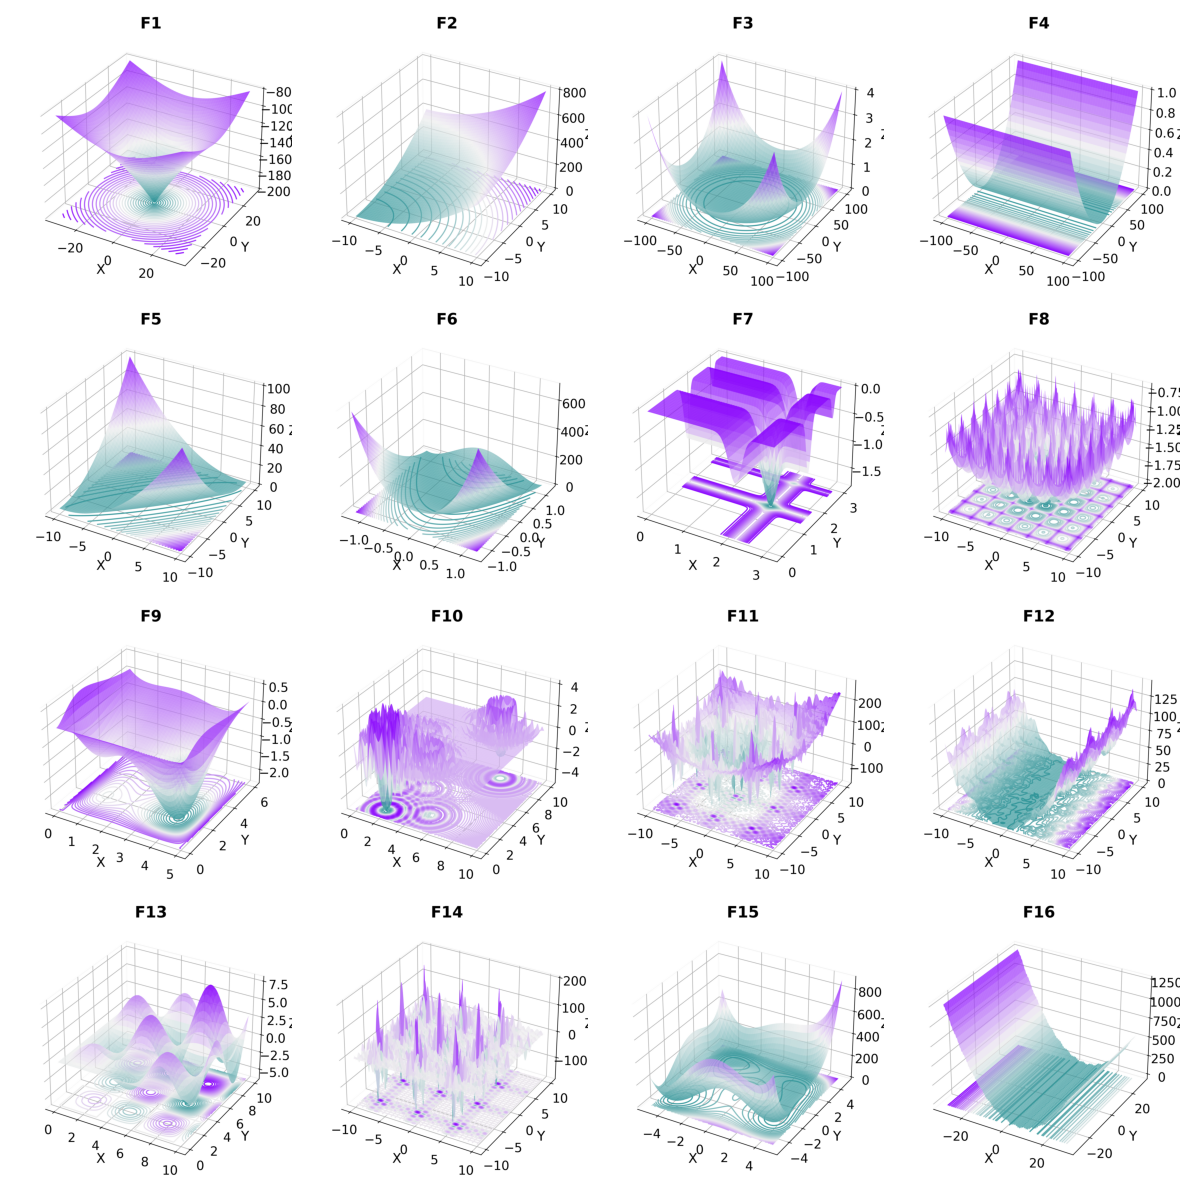

In [ ]:
fig, axs = plt.subplots(4, 4, figsize=(12, 12))

for i in range(16):
    row = i // 4
    col = i % 4

    img = plt.imread(path + f"figure/benchmark/F{i+1}.png")
    axs[row, col].imshow(img)
    axs[row, col].axis("off")

plt.tight_layout()
fig.savefig(path + f"figure/benchmarks.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
f_latexs

['f_{\\text{Ackley02}(x) = -200 e^{-0.02 \\sqrt{x_1^2 + x_2^2}}',
 'f_{\\text{Brent}}(x) = (x_1 + 10)^2 + (x_2 + 10)^2 + e^{(-x_1^2 -x_2^2)}',
 'f(x) = (\\sum_{i=1}^D x_i^2)^2',
 'f(x) = x_1^2 + 10^6\\sum_{i=2}^{n} x_i^2',
 'f_{\\text{Matyas}}(x) = 0.26(x_1^2 + x_2^2) - 0.48 x_1 x_2',
 'f_{\\text{Leon}}(\\mathbf{x}) = \\left(1 - x_{1}\\right)^{2} + 100 \\left(x_{2} - x_{1}^{2} \\right)^{2}',
 'f(x) = - x_{1} + 2 x_{2} + \\left(x_{1} - x_{2}\\right)^{2} + \\sin\\left(x_{1} + x_{2}\\right) + 1',
 'f(x) = - 0.0001 \\left(\\left|{e^{\\left|{100- \\frac{\\sqrt{x_{1}^{2} + x_{2}^{2}}}{\\pi}}\\right|} \\sin\\left(x_{1}\\right) \\sin\\left(x_{2}\\right)}\\right| + 1\\right)^{0.1}',
 'f(x) = \\left ( 1 - 8 x_1 + 7 x_1^2 - \\frac{7}{3} x_1^3 + \\frac{1}{4} x_1^4 \\right ) x_2^2 e^{-x_1}',
 'f_{\\text{Langermann}}(x) = - \\sum_{i=1}^{5} \\frac{c_i \\cos\\left\\{\\pi \\left[\\left(x_{1}- a_i\\right)^{2}  + \\left(x_{2} - b_i \\right)^{2}\\right]\\right\\}}{e^{\\frac{\\left( x_{1} - a_i\\right)^{2}